# 0. Import libraries

In [14]:
import pandas as pd
import os
import warnings
warnings.filterwarnings("ignore")
import sys
sys.path.insert(0, '/home/Algos/StrInt/')
from pyStrint.strint import strInt
from pyStrint import preprocess as pp
from pyStrint import plotting as pl

# 1. Load files

In [15]:
from pathlib import Path

inputDir = Path.cwd()/ 'demo'
outDir = inputDir / 'results'
if not os.path.exists(outDir):
    os.makedirs(outDir)
sc_exp = pd.read_csv(inputDir / 'SC_exp.tsv',sep = '\t',header=0,index_col=0)
sc_meta = pd.read_csv(inputDir / 'SC_meta.tsv',sep = '\t',header=0,index_col=0)
st_exp = pd.read_csv(inputDir / 'ST_exp.tsv',sep = '\t',header=0,index_col=0)
st_coord = pd.read_csv(inputDir / 'ST_coord.tsv',sep = '\t',header=0,index_col=0)
st_decon = pd.read_csv(inputDir / 'ST_weight.tsv',sep = '\t',header=0,index_col=0)
sc_distribution = pd.read_csv(f'{outDir}/SC_smurf.tsv',sep = '\t',header=0,index_col=0)

# 2. Get cell model

In [14]:
import smurf
operator = smurf.SMURF(n_features=15, estimate_only=True)
sc_distribution = operator.smurf_impute(sc_exp.T).T

Running SCEnd on 2686 cells and 32738 genes
normalizing data by library size...
preprocessing data...
number of iteration:  1 / 10
number of iteration:  2 / 10
number of iteration:  3 / 10
number of iteration:  4 / 10
number of iteration:  5 / 10
number of iteration:  6 / 10
number of iteration:  7 / 10
number of iteration:  8 / 10
number of iteration:  9 / 10
number of iteration:  10 / 10


In [18]:
sc_distribution.to_csv(f'{outDir}/SC_smurf.tsv',sep = '\t',header=True,index=True)

In [4]:
# or you can load the precomputed results
sc_distribution = pd.read_csv(f'{outDir}/SC_smurf.tsv',sep = '\t',header=0,index_col=0)

# 3. Preprocess

In [16]:
species  = 'Mouse'
sc_adata, st_adata, sc_ref, lr_df = pp.prep_all_adata(sc_exp = sc_exp, st_exp = st_exp, sc_distribution = sc_distribution,
                                                    sc_meta = sc_meta, st_coord = st_coord, SP = species)

AnnData object created:
  - Cells: 524
  - Genes: 9684
  - Species: Mouse
AnnData object created:
  - Cells: 72
  - Genes: 9684
  - Species: Mouse
Data clean is done! Using 9684 shared genes .


# 4. Cell selection

Cell selection parameters

In [17]:
st_tp = 'st'
num_per_spot = 7
repeat_penalty = int((st_exp.shape[0]*num_per_spot/sc_exp.shape[0]) * 10)
print('repeat_penalty:',repeat_penalty)

repeat_penalty: 9


In [18]:
outDir = str(outDir)
obj_spex = strInt(save_path = outDir, st_adata = st_adata, weight = st_decon,
                    sc_ref = sc_ref, sc_adata = sc_adata, cell_type_key = 'celltype', lr_df = lr_df,
                    st_tp = st_tp,species = species)
obj_spex.prep()

sc_ref and sc_adata has different genes, both data are subset to 9684 genes.
Parameters checked!
By setting k as 6, each spot has average 3.31 neighbors.


### use strint for cell selection

In [19]:
sc_agg_meta = obj_spex.select_cells(p = 0, mean_num_per_spot = num_per_spot, repeat_penalty = repeat_penalty)

	 Estimating the cell number in each spot by the deconvolution result.
	 SpexMod selects 3389 feature genes.
	 Init solution: max - 1.0000,     mean - 0.9317,     min - 0.7777
	 Swap selection start...
	 Swapped solution: max - 1.0000,     mean - 0.9059,     min - 0.7943


In [10]:
sc_agg_meta.to_csv(f'{outDir}/cell_mapping_meta.tsv',sep = '\t',header=True,index=True)

### [or] load the precomputed results from strint or other methods


In [8]:
sc_agg_meta = pd.read_csv(f'{outDir}/cell_mapping_meta.tsv',sep = '\t',header=0,index_col=0)
user_sc_exp = sc_exp.loc[sc_agg_meta['sc_id']]

In [9]:
sc_agg_meta = obj_spex.select_cells(user_sc_exp = user_sc_exp, user_sc_agg_meta = sc_agg_meta)

# 5. Refinement process

Gradient descent parameter recommandation 

In [20]:
delta, eta = [0.1, 0.0005]
max_rep = 30 # max_rep for gradient descent, choose accordingly.

In [21]:
expected_cell_num = st_adata.shape[0] *num_per_spot
ref_cell_num = sc_adata.shape[0]
lr_db = pp.load_lr_df(species = species) # full LR database
print(lr_db.shape)
print(lr_df.shape)

(2456, 3)
(1100, 3)


In [22]:
p1, p2, p3, p4 = pp.auto_tune_parameters(expected_cell_num/ref_cell_num, len(lr_df)/len(lr_db)) 
print(p1, p2, p3, p4)

0.04 0.65 0.22 0.09


In [23]:
refined_sc_exp, sc_agg_meta = obj_spex.gradient_descent(
                p1 = p1, p2 = p2, p3 = p3, p4 = p4, 
                delta = delta, eta = eta, 
                init_sc_embed = False,
                iteration = max_rep, k = 2, W_HVG = 2,
                left_range = 0, right_range = 5, steps = 1, dim = 2)
sc_agg_meta.to_csv(f'{outDir}/cell_mapping_meta.tsv',sep = '\t',header=True,index=True)

{"ts": "2026-08-14T16:32:38", "event": "run_gradient_sc_ref_alignment", "mode": "dataframe_input", "missing_sc_id_count": 0, "missing_sc_id_ratio": 0.0, "used_fallback": "sc_id_exact", "used_mean_broadcast": false, "nan_rows_filled": 0, "exception": "", "sc_ref_shape": [502, 9684]}
Initialize cell coordinates by affinity embedding...
Initial shape correlation: 0.96
{"ts": "2026-08-14T16:33:03", "event": "run_gradient_entry_diag", "entered_gradient": true, "mean_fill_happened": false, "mean_fill_reason": "sc_id_exact", "sc_ref_shape": [502, 9684], "sc_ref_has_nan": false, "sc_ref_has_inf": false, "sc_ref_broadcast_like": false, "alter_sc_exp_has_nan": false, "alter_sc_exp_has_inf": false}
Pre-update loss: 0.29300
{"ts": "2026-08-14T16:33:07", "event": "run_gradient_entry_diag", "entered_gradient": true, "mean_fill_happened": false, "mean_fill_reason": "sc_id_exact", "sc_ref_shape": [502, 9684], "sc_ref_has_nan": false, "sc_ref_has_inf": false, "sc_ref_broadcast_like": false, "alter_sc_e

# 6. Plotting

In [24]:
# species = 'Mouse'
# new_exp_fn = f'{outDir}/refined_sc_exp.tsv'
# new_meta_fn = f'{outDir}/cell_mapping_meta.tsv'

# refined_sc_exp = pd.read_csv(new_exp_fn,sep='\t',index_col=0,header=0)
# sc_agg_meta = pd.read_csv(new_meta_fn,sep='\t',index_col=0,header=0)

refine_adata = pp.make_adata(refined_sc_exp,sc_agg_meta,species,save_path = outDir, save_adata = False)
refine_adata.uns['tp_key'] = 'celltype'
# refine_adata.uns['rscript_path'] = '/apps/software/R/4.2.0-foss-2021b/bin/Rscript'
# refine_adata.uns['python_path'] = '/apps/software/Anaconda3/2022.05/bin/python'
# del alter_exp

AnnData object created:
  - Cells: 502
  - Genes: 9684
  - Species: Mouse


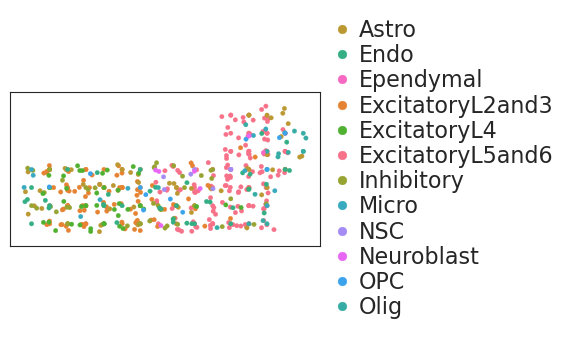

<Figure size 640x480 with 0 Axes>

In [25]:
pl.sc_celltype(refine_adata, color_map = None, tp_key = refine_adata.uns['tp_key'], figsize= (4,2),
        legend = True, size = 10, alpha = 1, savefig = True)